In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
sys.path.insert(0, str(Path('.')))

from ab_testing import Experiment, required_sample_size
from ab_testing.stats import (
    z_test, welch_t_test, mann_whitney_u_test, bootstrap_ci, wilson_ci, cuped,
)
from ab_testing.sequential import SequentialTest

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
# Constants and config
DATA_DIR   = Path('..') / 'data' / 'synthetic'
ALPHA      = 0.05
POWER      = 0.80
SEED       = 42
rng        = np.random.default_rng(SEED)

In [3]:

# Load synthetic data
users  = pd.read_csv(DATA_DIR / 'users.csv',  parse_dates=['signup_at', 'churn_at'])
orders = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['billed_at'])

baseline_cvr = users['converted'].mean()
print(f"{len(users):,} users")
print(f"Baseline conversion rate : {baseline_cvr:.2%}")
print(f"Avg revenue (all orders) : ${orders['amount_usd'].mean():.2f}")

5,000 users
Baseline conversion rate : 23.00%
Avg revenue (all orders) : $118.64


---
## Part 1 — Experiment Design & Power Analysis

Before running an experiment, answer two questions:
1. How many users do I need per variant to detect a meaningful effect?
2. How long will that take given current traffic?

Getting this wrong in either direction is costly:
- **Under-powered** → you miss real effects (false negatives)
- **Over-powered** → you waste time and expose users to an inferior variant

Sample size required
  per variant:   2,451
  total:         4,902
  baseline rate: 23.00%
  MDE:           +0.0345 (+15.0% relative)
  α=0.05  power=80%
  estimated duration: 13 days



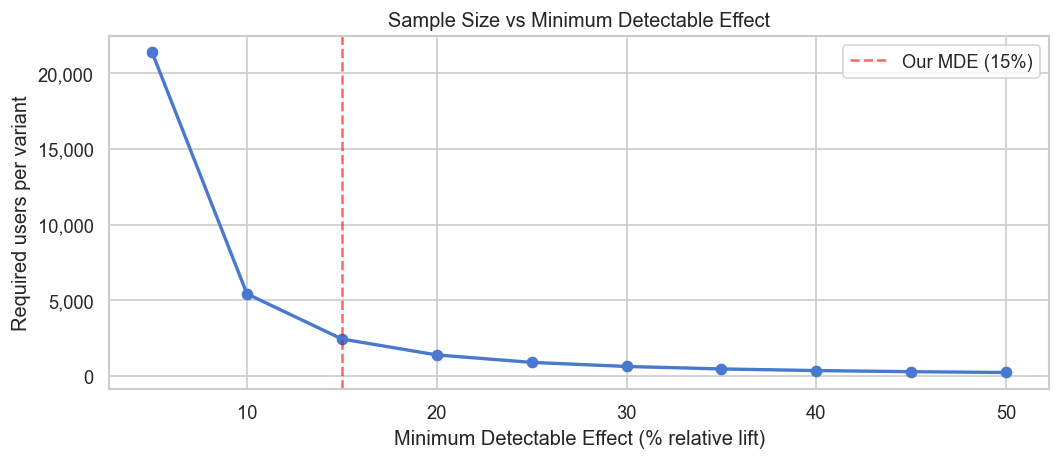

In [4]:
# Sample size for a 15% relative lift on conversion rate
plan = required_sample_size(
    baseline_rate=baseline_cvr,
    mde_relative=0.15,
    alpha=ALPHA,
    power=POWER,
    daily_traffic_per_variant=200,
)
print(plan)

# Show how required n changes with MDE
mdes  = np.arange(0.05, 0.51, 0.05)
ns    = [required_sample_size(baseline_cvr, mde_relative=m, alpha=ALPHA, power=POWER).n_per_variant for m in mdes]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mdes * 100, ns, marker='o', linewidth=2)
ax.axvline(15, color='red', linestyle='--', alpha=0.6, label='Our MDE (15%)')
ax.set_xlabel('Minimum Detectable Effect (% relative lift)')
ax.set_ylabel('Required users per variant')
ax.set_title('Sample Size vs Minimum Detectable Effect')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

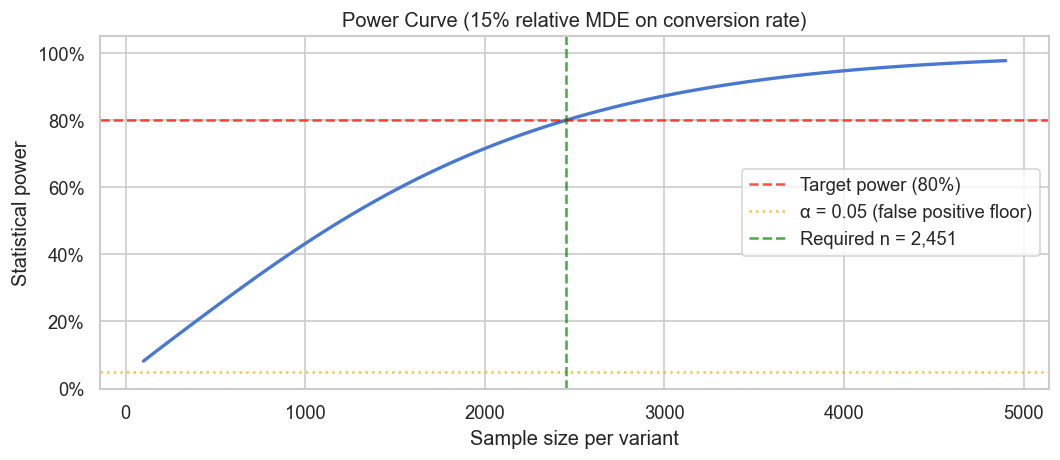

In [5]:
# Power curve: how does statistical power grow with sample size?
from scipy.stats import norm as _norm

true_effect = baseline_cvr * 0.15          # 15% relative lift → absolute MDE
pooled_p    = baseline_cvr + true_effect / 2
se_fn       = lambda n: np.sqrt(2 * pooled_p * (1 - pooled_p) / n)
z_crit      = _norm.ppf(1 - ALPHA / 2)

ns_range = np.arange(100, plan.n_per_variant * 2, 50)
power_at_n = 1 - _norm.cdf(z_crit - true_effect / se_fn(ns_range))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ns_range, power_at_n, linewidth=2)
ax.axhline(POWER, color='red',    linestyle='--', alpha=0.7, label=f'Target power ({POWER:.0%})')
ax.axhline(0.05,  color='orange', linestyle=':',  alpha=0.7, label='α = 0.05 (false positive floor)')
ax.axvline(plan.n_per_variant, color='green', linestyle='--', alpha=0.7,
           label=f'Required n = {plan.n_per_variant:,}')
ax.set_xlabel('Sample size per variant')
ax.set_ylabel('Statistical power')
ax.set_title('Power Curve (15% relative MDE on conversion rate)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 2 — Binary Metric Test (Conversion Rate)

The most common A/B test: did the variant change a binary outcome (converted / not converted)?

**Test**: Two-proportion z-test  
**Effect size**: Difference in proportions  
**Confidence intervals**: Wilson score CI (preferred over normal approximation for proportions)

In [6]:
# Simulate a binary A/B test with a real effect
n = plan.n_per_variant
true_lift = 0.18   # 18% relative lift

ctrl_cvr  = baseline_cvr
treat_cvr = baseline_cvr * (1 + true_lift)

ctrl_obs  = rng.binomial(1, ctrl_cvr,  size=n)
treat_obs = rng.binomial(1, treat_cvr, size=n)

result = z_test(ctrl_obs.sum(), n, treat_obs.sum(), n, alpha=ALPHA)
print(result)

# Wilson CIs per arm
c_lo, c_hi = wilson_ci(ctrl_obs.sum(),  n)
t_lo, t_hi = wilson_ci(treat_obs.sum(), n)

print(f"\nControl   {ctrl_obs.mean():.3%}  95% CI [{c_lo:.3%}, {c_hi:.3%}]")
print(f"Treatment {treat_obs.mean():.3%}  95% CI [{t_lo:.3%}, {t_hi:.3%}]")

two_proportion_z_test: effect=0.0208 [-0.0033, 0.0450], p=0.0914 (not significant at α=0.05)

Control   23.705%  95% CI [22.063%, 25.429%]
Treatment 25.785%  95% CI [24.092%, 27.554%]


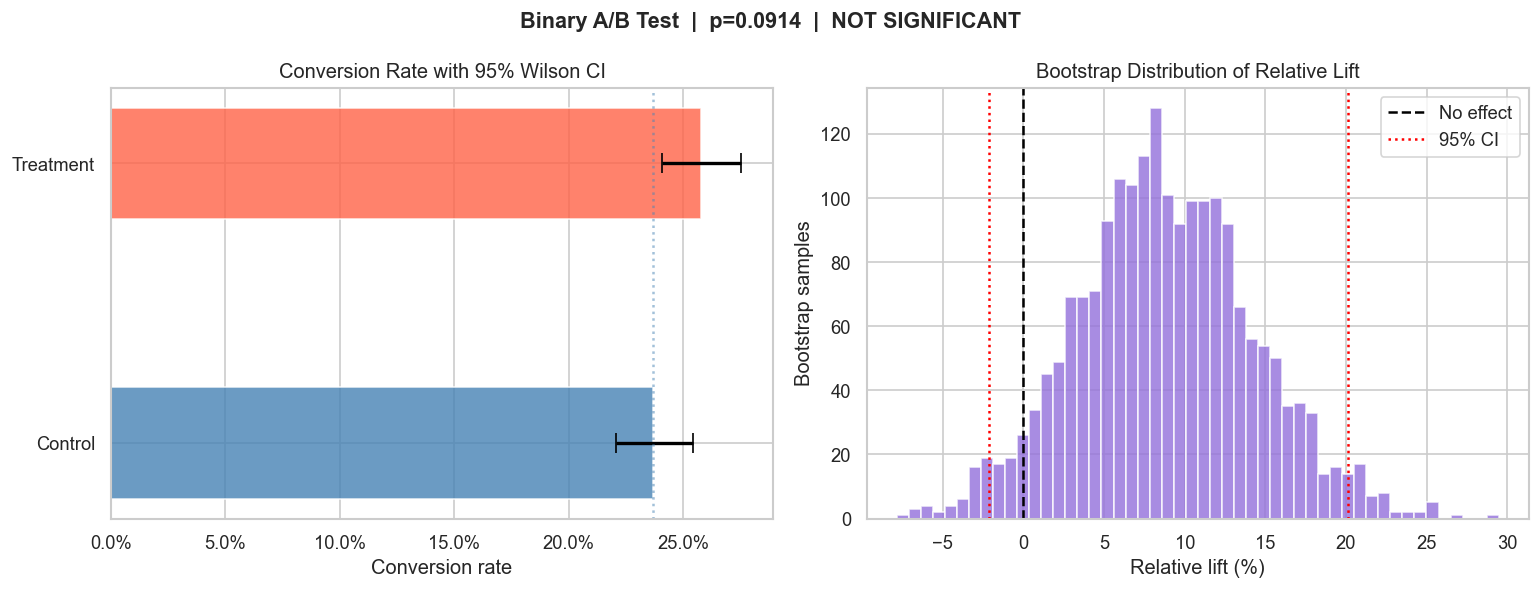

In [7]:
# Visualise: conversion rates with Wilson confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: CI comparison
ax = axes[0]
labels  = ['Control', 'Treatment']
means   = [ctrl_obs.mean(), treat_obs.mean()]
lowers  = [means[0] - c_lo, means[1] - t_lo]
uppers  = [c_hi - means[0], t_hi - means[1]]
colors  = ['steelblue', 'tomato']

for i, (label, mean, lo, hi, color) in enumerate(zip(labels, means, lowers, uppers, colors)):
    ax.barh(i, mean, color=color, alpha=0.8, height=0.4)
    ax.errorbar(mean, i, xerr=[[lo], [hi]], fmt='none', color='black', capsize=6, linewidth=2)

ax.set_yticks([0, 1])
ax.set_yticklabels(labels)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Conversion rate')
ax.set_title('Conversion Rate with 95% Wilson CI')
ax.axvline(ctrl_obs.mean(), color='steelblue', linestyle=':', alpha=0.5)

# Right: lift distribution via bootstrap
ax = axes[1]
n_boot = 2000
boot_ctrl  = rng.choice(ctrl_obs,  (n_boot, n), replace=True).mean(axis=1)
boot_treat = rng.choice(treat_obs, (n_boot, n), replace=True).mean(axis=1)
boot_lift  = (boot_treat - boot_ctrl) / boot_ctrl * 100

ax.hist(boot_lift, bins=50, color='mediumpurple', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='No effect')
ax.axvline(np.percentile(boot_lift, 2.5),  color='red', linestyle=':', label='95% CI')
ax.axvline(np.percentile(boot_lift, 97.5), color='red', linestyle=':')
ax.set_xlabel('Relative lift (%)')
ax.set_ylabel('Bootstrap samples')
ax.set_title('Bootstrap Distribution of Relative Lift')
ax.legend()

status = 'SIGNIFICANT ✓' if result.significant else 'NOT SIGNIFICANT'
fig.suptitle(f'Binary A/B Test  |  p={result.p_value:.4f}  |  {status}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — Continuous Metric Test (Revenue per User)

Revenue is skewed, noisy, and rarely normal. Three tests are shown below:

| Test | When to use |
|------|-------------|
| Welch t-test | Means differ; roughly normal or large n (CLT applies) |
| Mann-Whitney U | Medians / rank distributions; non-normal, heavy tails |
| Bootstrap CI | No distributional assumptions; best for communication |

In [8]:
# Simulate a revenue experiment (log-normal revenue, real $3 treatment effect)
n_rev         = 800
true_lift_rev = 3.0

pre_rev  = rng.lognormal(mean=3.5, sigma=1.2, size=n_rev * 2)
noise    = rng.normal(0, 0.5, size=n_rev * 2)
post_rev = pre_rev * 0.7 + noise
post_rev[n_rev:] += true_lift_rev

ctrl_rev  = post_rev[:n_rev]
treat_rev = post_rev[n_rev:]

t_result         = welch_t_test(ctrl_rev, treat_rev)
mw_result        = mann_whitney_u_test(ctrl_rev, treat_rev)
bs_lo, bs_hi     = bootstrap_ci(ctrl_rev, treat_rev, statistic='mean', n_bootstrap=2000, seed=SEED)

print('Welch t-test  :', t_result)
print('Mann-Whitney  :', mw_result)
print(f'Bootstrap CI  : [{bs_lo:.4f}, {bs_hi:.4f}]')

Welch t-test  : welch_t_test: effect=2.3499 [-5.1209, 9.8208], p=0.5373 (not significant at α=0.05)
Mann-Whitney  : mann_whitney_u: effect=3.6035 [0.4533, 7.3996], p=0.0005 (SIGNIFICANT at α=0.05)
Bootstrap CI  : [-5.2551, 9.7570]


/var/folders/k6/ncthlzgj0ls7q2l_1jsxr8ym0000gn/T/ipykernel_55599/973625378.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl_rev, treat_rev], labels=['Control', 'Treatment'],
/var/folders/k6/ncthlzgj0ls7q2l_1jsxr8ym0000gn/T/ipykernel_55599/973625378.py:35: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/Users/Viola/Documents/Code/data-bedrock/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


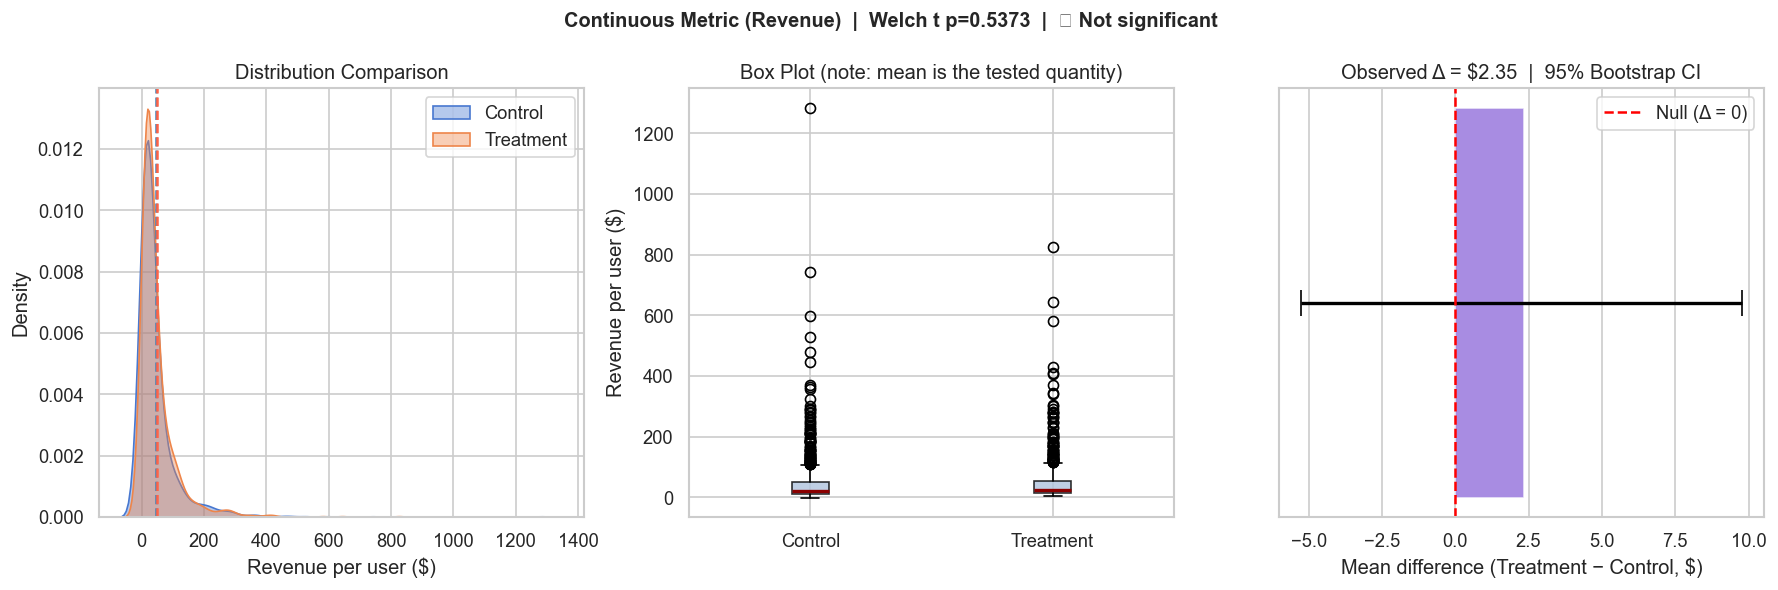

In [9]:
# Visualise revenue distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
sns.kdeplot(ctrl_rev,  ax=ax, label='Control',   fill=True, alpha=0.4)
sns.kdeplot(treat_rev, ax=ax, label='Treatment', fill=True, alpha=0.4)
ax.axvline(ctrl_rev.mean(),  linestyle='--', color='steelblue', linewidth=1.5)
ax.axvline(treat_rev.mean(), linestyle='--', color='tomato',    linewidth=1.5)
ax.set_xlabel('Revenue per user ($)')
ax.set_title('Distribution Comparison')
ax.legend()

ax = axes[1]
ax.boxplot([ctrl_rev, treat_rev], labels=['Control', 'Treatment'],
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', alpha=0.8),
           medianprops=dict(color='darkred', linewidth=2))
ax.set_ylabel('Revenue per user ($)')
ax.set_title('Box Plot (note: mean is the tested quantity)')

ax       = axes[2]
obs_diff = treat_rev.mean() - ctrl_rev.mean()
ax.barh([0], [obs_diff], height=0.3, color='mediumpurple', alpha=0.8)
ax.errorbar(obs_diff, 0, xerr=[[obs_diff - bs_lo], [bs_hi - obs_diff]],
            fmt='none', color='black', capsize=8, linewidth=2)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Null (Δ = 0)')
ax.set_yticks([])
ax.set_xlabel('Mean difference (Treatment − Control, $)')
ax.set_title(f'Observed Δ = ${obs_diff:.2f}  |  95% Bootstrap CI')
ax.legend()

sig = '✓ Significant' if t_result.significant else '✗ Not significant'
fig.suptitle(f'Continuous Metric (Revenue)  |  Welch t p={t_result.p_value:.4f}  |  {sig}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4 — Variance Reduction with CUPED

CUPED (Controlled-experiment Using Pre-Experiment Data) uses a pre-experiment covariate to remove noise that is unrelated to the treatment. Mathematically it is ANCOVA.

**Why it matters**: For the same sample size, CUPED can double or triple the effective statistical power — equivalent to running the experiment for twice as long.

In [10]:
# CUPED: compare variance and p-value before/after adjustment
pre_ctrl  = pre_rev[:n_rev]
pre_treat = pre_rev[n_rev:]

raw_result   = welch_t_test(ctrl_rev, treat_rev)
cuped_result = cuped(ctrl_rev, treat_rev, pre_ctrl, pre_treat)

all_post = np.concatenate([ctrl_rev, treat_rev])
all_pre  = np.concatenate([pre_ctrl, pre_treat])
theta    = np.cov(all_post, all_pre)[0, 1] / np.var(all_pre)
ctrl_adj  = ctrl_rev  - theta * (pre_ctrl  - all_pre.mean())
treat_adj = treat_rev - theta * (pre_treat - all_pre.mean())

var_raw   = np.var(all_post)
var_cuped = np.var(np.concatenate([ctrl_adj, treat_adj]))
reduction = 1 - var_cuped / var_raw

raw_ci_width   = raw_result.ci_upper   - raw_result.ci_lower
cuped_ci_width = cuped_result.ci_upper - cuped_result.ci_lower

print(f'Theta (covariate weight)  : {theta:.4f}')
print(f'Variance reduction        : {reduction:.1%}')
print(f'\nWithout CUPED → p={raw_result.p_value:.4f}   95% CI width={raw_ci_width:.4f}')
print(f'With    CUPED → p={cuped_result.p_value:.4f}   95% CI width={cuped_ci_width:.4f}')

Theta (covariate weight)  : 0.7003
Variance reduction        : 100.0%

Without CUPED → p=0.5373   95% CI width=14.9417
With    CUPED → p=0.0000   95% CI width=0.0959


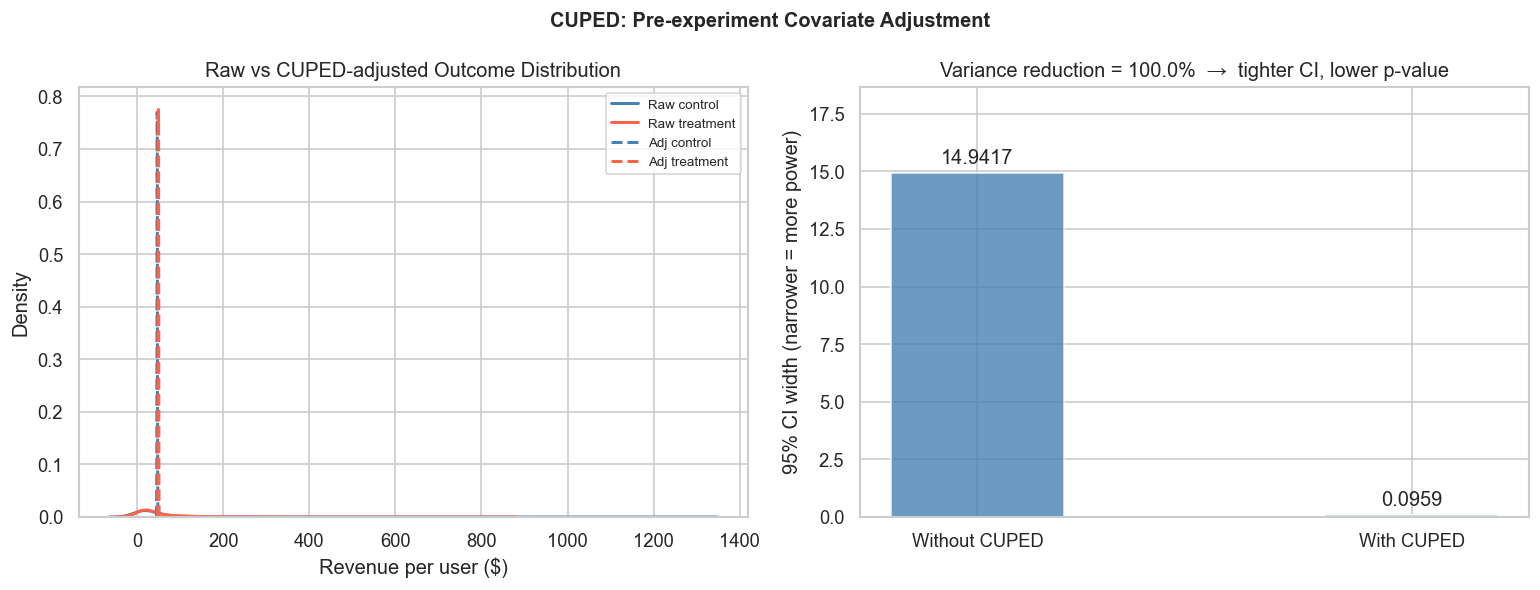

In [11]:
# Visualise CUPED variance reduction
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for series, color, ls, label in [
    (ctrl_rev,  'steelblue', '-',  'Raw control'),
    (treat_rev, 'tomato',    '-',  'Raw treatment'),
    (ctrl_adj,  'steelblue', '--', 'Adj control'),
    (treat_adj, 'tomato',    '--', 'Adj treatment'),
]:
    sns.kdeplot(series, ax=ax, color=color, linestyle=ls, label=label, linewidth=1.8)
ax.set_xlabel('Revenue per user ($)')
ax.set_title('Raw vs CUPED-adjusted Outcome Distribution')
ax.legend(fontsize=8)

ax        = axes[1]
ci_widths = [raw_ci_width, cuped_ci_width]
methods   = ['Without CUPED', 'With CUPED']
bars      = ax.bar(methods, ci_widths, color=['steelblue', 'mediumseagreen'], alpha=0.8, width=0.4)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylabel('95% CI width (narrower = more power)')
ax.set_title(f'Variance reduction = {reduction:.1%}  →  tighter CI, lower p-value')
ax.set_ylim(0, max(ci_widths) * 1.25)

plt.suptitle('CUPED: Pre-experiment Covariate Adjustment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 5 — Multiple Testing Correction

When you test many metrics simultaneously, the chance of at least one false positive grows quickly:

$$P(\geq 1 \text{ false positive}) = 1 - (1 - \alpha)^k$$

With α=0.05 and 10 metrics, that is **40%**.

| Correction | Controls | Use when |
|-----------|----------|----------|
| Bonferroni | Family-wise error rate (FWER) | Few metrics; must avoid any false positives |
| Benjamini-Hochberg (BH) | False Discovery Rate (FDR) | Many metrics; some false positives acceptable |

In [12]:
# Simulate 10 metrics; 3 have a real effect, 7 are null
n_metrics   = 10
n_per_group = 500
true_effects = [2.0, 3.0, 1.5] + [0.0] * 7   # first 3 are real

p_values = []
metric_names = [f'metric_{i+1}' for i in range(n_metrics)]

for effect in true_effects:
    c = rng.normal(10, 3, n_per_group)
    t = rng.normal(10 + effect, 3, n_per_group)
    res = welch_t_test(c, t)
    p_values.append(res.p_value)

p_arr = np.array(p_values)

# Apply corrections
_, p_bonf, _, _ = multipletests(p_arr, alpha=ALPHA, method='bonferroni')
_, p_bh,   _, _ = multipletests(p_arr, alpha=ALPHA, method='fdr_bh')

results_df = pd.DataFrame({
    'metric':        metric_names,
    'has_effect':    ['yes'] * 3 + ['no'] * 7,
    'raw_p':         p_arr.round(4),
    'bonferroni_p':  p_bonf.round(4),
    'bh_p':          p_bh.round(4),
    'sig_raw':       p_arr     < ALPHA,
    'sig_bonf':      p_bonf    < ALPHA,
    'sig_bh':        p_bh      < ALPHA,
})
print(results_df.to_string(index=False))

   metric has_effect  raw_p  bonferroni_p   bh_p  sig_raw  sig_bonf  sig_bh
 metric_1        yes 0.0000        0.0000 0.0000     True      True    True
 metric_2        yes 0.0000        0.0000 0.0000     True      True    True
 metric_3        yes 0.0000        0.0000 0.0000     True      True    True
 metric_4         no 0.0512        0.5118 0.1180    False     False   False
 metric_5         no 0.4872        1.0000 0.6118    False     False   False
 metric_6         no 0.6478        1.0000 0.7197    False     False   False
 metric_7         no 0.8060        1.0000 0.8060    False     False   False
 metric_8         no 0.0590        0.5901 0.1180    False     False   False
 metric_9         no 0.3104        1.0000 0.5174    False     False   False
metric_10         no 0.4894        1.0000 0.6118    False     False   False


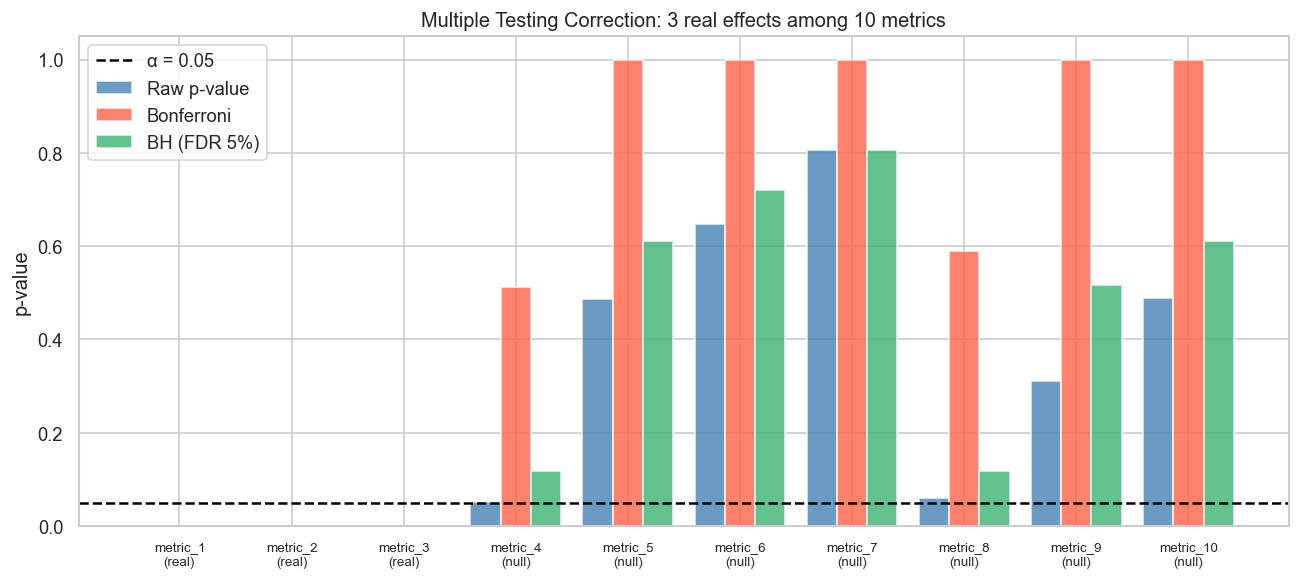


Significant detections:
  Raw p-values   : 3 of 10  (includes false positives)
  Bonferroni     : 3 of 10
  BH / FDR 5%    : 3 of 10


In [13]:
# Visualise p-values before and after correction
fig, ax = plt.subplots(figsize=(11, 5))

x     = np.arange(n_metrics)
width = 0.27

b1 = ax.bar(x - width, p_arr,  width, label='Raw p-value',   color='steelblue', alpha=0.8)
b2 = ax.bar(x,         p_bonf, width, label='Bonferroni',    color='tomato',    alpha=0.8)
b3 = ax.bar(x + width, p_bh,   width, label='BH (FDR 5%)',   color='mediumseagreen', alpha=0.8)

ax.axhline(ALPHA, color='black', linestyle='--', linewidth=1.5, label=f'α = {ALPHA}')
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{m}\n(real)' if e == 'yes' else f'{m}\n(null)'
     for m, e in zip(metric_names, results_df['has_effect'])],
    fontsize=8
)
ax.set_ylabel('p-value')
ax.set_title('Multiple Testing Correction: 3 real effects among 10 metrics')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSignificant detections:")
print(f"  Raw p-values   : {results_df['sig_raw'].sum()} of {n_metrics}  (includes false positives)")
print(f"  Bonferroni     : {results_df['sig_bonf'].sum()} of {n_metrics}")
print(f"  BH / FDR 5%    : {results_df['sig_bh'].sum()} of {n_metrics}")

---
## Part 6 — Sequential Testing (Always-Valid p-values)

**The peeking problem**: if you check p-values daily and stop when p < 0.05, your actual false positive rate is much higher than 5%.

**mSPRT** (mixture Sequential Probability Ratio Test) produces *always-valid* p-values: you can stop at any time without inflating the false positive rate.

This section shows both the peeking problem and the mSPRT solution side by side.

In [14]:
# Fixed-horizon peeking: simulate false positive rate when peeking daily
n_sims           = 1000
days             = 30
n_per_day        = 50
false_pos_peek   = 0
false_pos_fixed  = 0

rng2 = np.random.default_rng(99)
for _ in range(n_sims):
    stopped_early = False
    c_all, t_all  = [], []
    for _ in range(days):
        c_all.extend(rng2.binomial(1, 0.10, n_per_day).tolist())
        t_all.extend(rng2.binomial(1, 0.10, n_per_day).tolist())
        if len(c_all) >= 10:
            c_arr, t_arr = np.array(c_all), np.array(t_all)
            p = z_test(int(c_arr.sum()), len(c_arr), int(t_arr.sum()), len(t_arr)).p_value
            if p < ALPHA:
                stopped_early = True
                break
    if stopped_early:
        false_pos_peek += 1
    c_fixed = rng2.binomial(1, 0.10, days * n_per_day)
    t_fixed = rng2.binomial(1, 0.10, days * n_per_day)
    if z_test(int(c_fixed.sum()), len(c_fixed), int(t_fixed.sum()), len(t_fixed)).p_value < ALPHA:
        false_pos_fixed += 1

print(f'False positive rate (peek every day) : {false_pos_peek / n_sims:.1%}  ← inflated!')
print(f'False positive rate (fixed horizon)  : {false_pos_fixed / n_sims:.1%}  ← nominal α')

False positive rate (peek every day) : 30.1%  ← inflated!
False positive rate (fixed horizon)  : 5.1%  ← nominal α


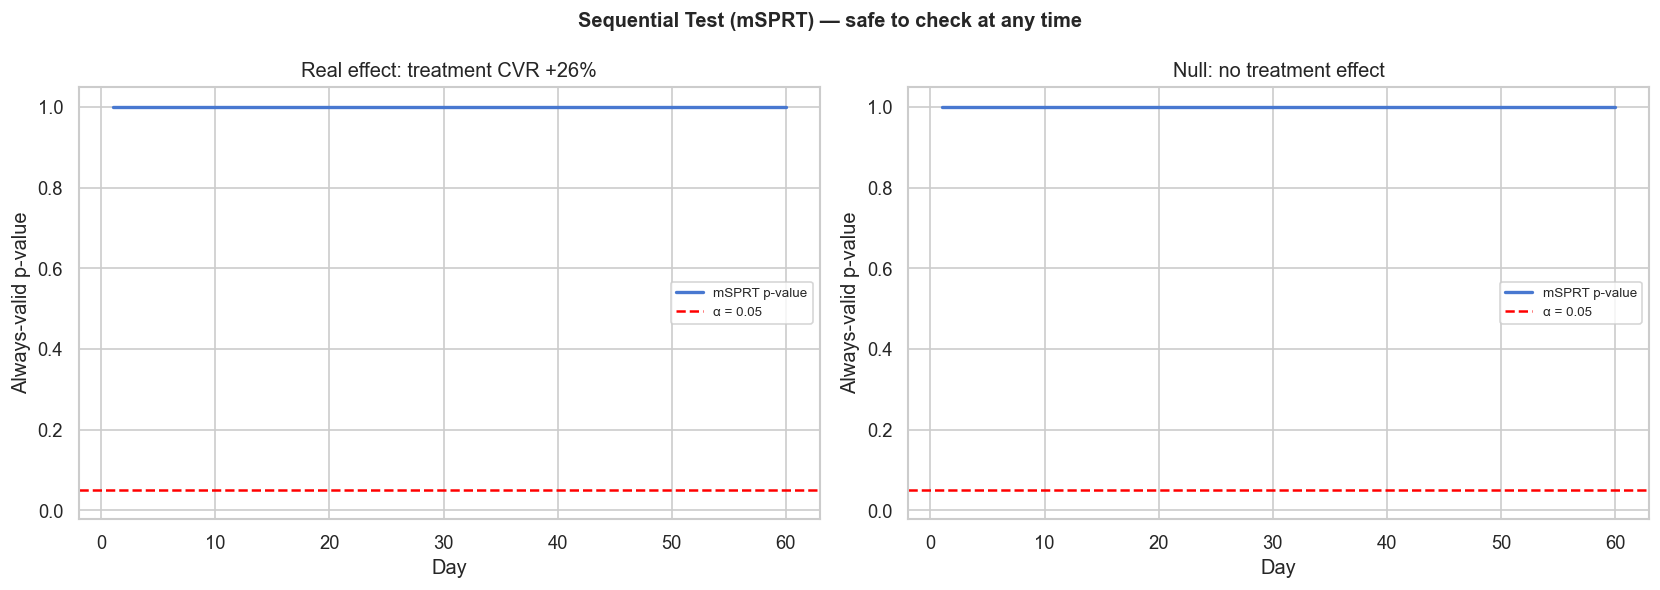

In [15]:
# Sequential test (mSPRT): valid stopping at any time
# Scenario A: real effect (treatment is better)
# Scenario B: null (no effect)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scenario, ctrl_rate, treat_rate, title in [
    (axes[0], 'A', 0.05, 0.063, 'Real effect: treatment CVR +26%'),
    (axes[1], 'B', 0.05, 0.05,  'Null: no treatment effect'),
]:
    seq = SequentialTest(alpha=ALPHA)
    p_vals, effects, days_list = [], [], []
    stopped_day = None

    for day in range(1, 61):
        c = rng.binomial(1, ctrl_rate,  size=100)
        t = rng.binomial(1, treat_rate, size=100)
        r = seq.update(c, t)
        p_vals.append(r.p_value)
        effects.append(r.effect_size)
        days_list.append(day)
        if r.significant and stopped_day is None:
            stopped_day = day

    ax.plot(days_list, p_vals, linewidth=2, label='mSPRT p-value')
    ax.axhline(ALPHA, color='red', linestyle='--', linewidth=1.5, label=f'α = {ALPHA}')
    if stopped_day:
        ax.axvline(stopped_day, color='green', linestyle=':', linewidth=2,
                   label=f'Early stop (day {stopped_day})')
    ax.set_xlabel('Day')
    ax.set_ylabel('Always-valid p-value')
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8)

plt.suptitle('Sequential Test (mSPRT) — safe to check at any time', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 7 — Diagnostic Checks

Before trusting any A/B result, run these checks:

| Check | What it detects |
|-------|----------------|
| A/A test (p-value distribution) | Whether your test is miscalibrated — p-values under the null should be uniform |
| Sample Ratio Mismatch (SRM) | Whether randomisation is broken — groups should be equal size |
| Pre-experiment balance | Whether groups were already different before the experiment started |

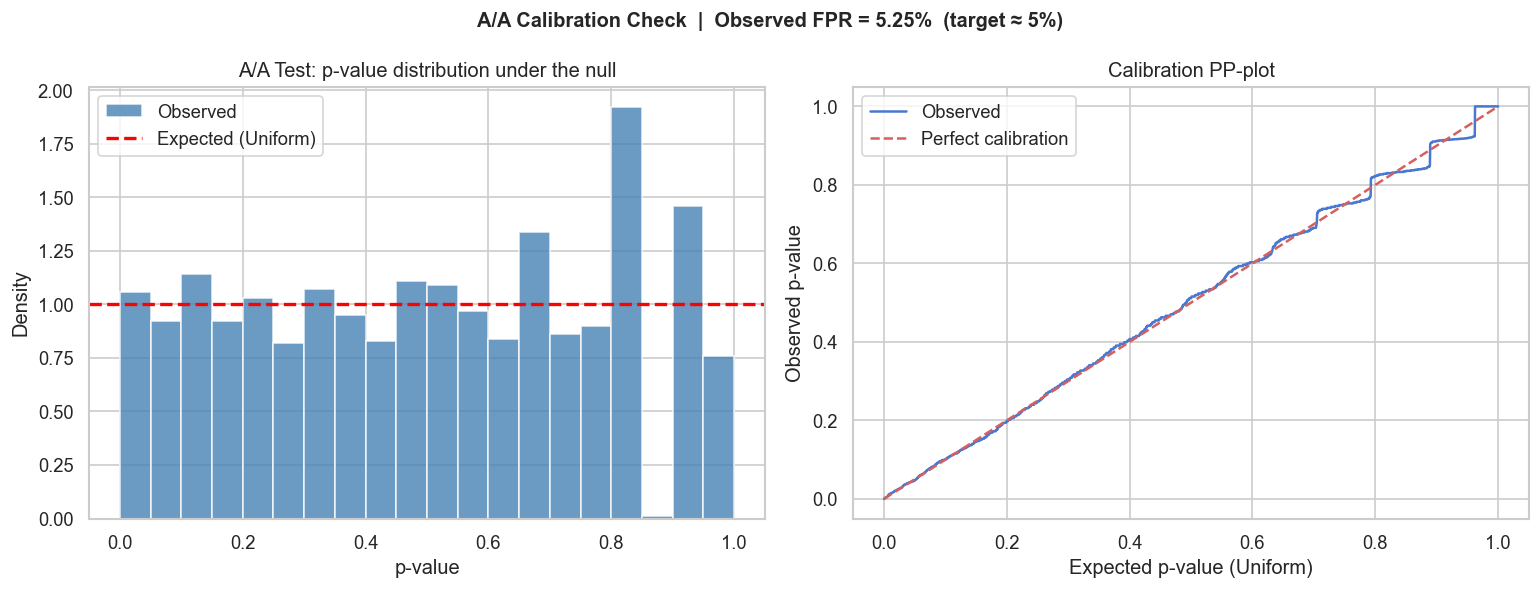

In [16]:
# A/A test: p-value distribution under the null should be Uniform(0, 1)
n_aa_sims = 2000
aa_pvals  = []

for _ in range(n_aa_sims):
    c = rng.binomial(1, 0.10, 500)
    t = rng.binomial(1, 0.10, 500)
    aa_pvals.append(z_test(int(c.sum()), len(c), int(t.sum()), len(t)).p_value)

aa_pvals = np.array(aa_pvals)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(aa_pvals, bins=20, density=True, color='steelblue', alpha=0.8, edgecolor='white', label='Observed')
ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Expected (Uniform)')
ax.set_xlabel('p-value')
ax.set_ylabel('Density')
ax.set_title('A/A Test: p-value distribution under the null')
ax.legend()

ax = axes[1]
sorted_p = np.sort(aa_pvals)
expected = np.linspace(0, 1, len(sorted_p))
ax.plot(expected, sorted_p, linewidth=1.5, label='Observed')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect calibration')
ax.set_xlabel('Expected p-value (Uniform)')
ax.set_ylabel('Observed p-value')
ax.set_title('Calibration PP-plot')
ax.legend()

fpr = (aa_pvals < ALPHA).mean()
fig.suptitle(f'A/A Calibration Check  |  Observed FPR = {fpr:.2%}  (target ≈ {ALPHA:.0%})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Sample Ratio Mismatch (SRM) check
# If the experiment assigns 50/50 but groups differ significantly → randomisation is broken
def srm_check(n_ctrl: int, n_treat: int, expected_split: float = 0.5) -> dict:
    n_total   = n_ctrl + n_treat
    exp_ctrl  = n_total * expected_split
    exp_treat = n_total * (1 - expected_split)
    chi2, p   = stats.chisquare([n_ctrl, n_treat], f_exp=[exp_ctrl, exp_treat])
    return {'n_ctrl': n_ctrl, 'n_treat': n_treat, 'expected_each': int(n_total / 2),
            'chi2': round(chi2, 3), 'p_value': round(p, 4),
            'srm_detected': p < 0.01}

print("--- No SRM (healthy randomisation) ---")
print(srm_check(4983, 5017))

print("\n--- SRM detected (e.g. a bot filter applied only to treatment) ---")
print(srm_check(5000, 4200))

--- No SRM (healthy randomisation) ---
{'n_ctrl': 4983, 'n_treat': 5017, 'expected_each': 5000, 'chi2': np.float64(0.116), 'p_value': np.float64(0.7339), 'srm_detected': np.False_}

--- SRM detected (e.g. a bot filter applied only to treatment) ---
{'n_ctrl': 5000, 'n_treat': 4200, 'expected_each': 4600, 'chi2': np.float64(69.565), 'p_value': np.float64(0.0), 'srm_detected': np.True_}


In [18]:
# Summary: all tests run in this notebook
summary = pd.DataFrame([
    {'section': 'Experiment Design',  'method': 'Sample size calculator',      'result': f'n={plan.n_per_variant:,} per variant'},
    {'section': 'Binary metric',      'method': 'Two-proportion z-test',        'result': f'p={result.p_value:.4f}  sig={result.significant}'},
    {'section': 'Binary metric',      'method': 'Wilson CI',                    'result': f'ctrl [{c_lo:.3%},{c_hi:.3%}]  treat [{t_lo:.3%},{t_hi:.3%}]'},
    {'section': 'Continuous metric',  'method': 'Welch t-test',                 'result': f'p={t_result.p_value:.4f}  sig={t_result.significant}'},
    {'section': 'Continuous metric',  'method': 'Mann-Whitney U',               'result': f'p={mw_result.p_value:.4f}  sig={mw_result.significant}'},
    {'section': 'Continuous metric',  'method': 'Bootstrap CI (mean diff)',      'result': f'[{bs_lo:.3f}, {bs_hi:.3f}]'},
    {'section': 'CUPED',              'method': 'Pre-experiment covariate adj', 'result': f'CI width {raw_ci_width:.4f} → {cuped_ci_width:.4f}  ({reduction:.1%} var reduction)'},
    {'section': 'Multiple testing',   'method': 'Bonferroni + BH correction',   'result': f'{results_df.sig_bh.sum()} / {n_metrics} metrics significant (BH)'},
    {'section': 'Sequential testing', 'method': 'mSPRT always-valid p-value',   'result': 'Safe to monitor daily'},
    {'section': 'Diagnostics',        'method': 'A/A calibration check',        'result': f'FPR = {fpr:.2%}  (target {ALPHA:.0%})'},
    {'section': 'Diagnostics',        'method': 'Sample Ratio Mismatch (SRM)',  'result': 'χ² test on group sizes'},
])
summary

,section,method,result
0,Experiment Design,Sample size calculator,"n=2,451 per variant"
1,Binary metric,Two-proportion z-test,p=0.0914 sig=False
2,Binary metric,Wilson CI,"ctrl [22.063%,25.429%] treat [24.092%,27.554%]"
3,Continuous metric,Welch t-test,p=0.5373 sig=False
4,Continuous metric,Mann-Whitney U,p=0.0005 sig=True
5,Continuous metric,Bootstrap CI (mean diff),"[-5.255, 9.757]"
6,CUPED,Pre-experiment covariate adj,CI width 14.9417 → 0.0959 (100.0% var reduction)
7,Multiple testing,Bonferroni + BH correction,3 / 10 metrics significant (BH)
8,Sequential testing,mSPRT always-valid p-value,Safe to monitor daily
9,Diagnostics,A/A calibration check,FPR = 5.25% (target 5%)
